## Preprocessing of CDC survey data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.utils import shuffle

In [ ]:
df_raw = pd.read_sas('LLCP2020.XPT')

In [3]:
df_raw = df_raw.rename(columns = {'_SEX':'Sex','GENHLTH':'GeneralHealth','HLTHPLN1':'HealthPlan',
                                    '_PHYS14D':'PhysicalHealth','_TOTINDA':'PhysicalActivity','SLEPTIM1':'SleepTime','CVDSTRK3':'Stroke','CHCSCNCR':'SkinCancer',
                                    'CHCOCNCR':'Cancer','CHCCOPD2':'COPD','CHCKDNY2':'KidneyDisease','DIABETE4':'Diabetic',
                                    'MARIJAN1':'MarijuanaUsage','_RACE':'Race','_AGEG5YR':'AgeGroup',
                                    '_LTASTH1':'Asthma','DIFFWALK':'DifficultyWalking','DRNKANY5':'AlcoholConsumption','HTM4':'Height','CVDCRHD4':'HeartDisease',
                                    'ECIGNOW':'E-Cigarette','_RFSMOK3':'Smoking','_MENT14D':'MentalHealth','WTKG3':'Weight','_BMI5':'BMI'
                                    })

Select promising features only

In [4]:
df = df_raw[['HeartDisease','BMI','Sex','GeneralHealth','MentalHealth','PhysicalHealth','Race','AgeGroup',
                        'PhysicalActivity','Stroke','SkinCancer','Cancer','SleepTime','COPD',
                        'KidneyDisease','Diabetic','Asthma','E-Cigarette','MarijuanaUsage',
                        'DifficultyWalking','AlcoholConsumption','Smoking','Weight','Height']]

## Explore features

In [5]:
df.isnull().sum()

HeartDisease               3
BMI                    41357
Sex                        0
GeneralHealth              8
MentalHealth               0
PhysicalHealth             0
Race                       1
AgeGroup                   0
PhysicalActivity           0
Stroke                     3
SkinCancer                 3
Cancer                     3
SleepTime                  3
COPD                       5
KidneyDisease              6
Diabetic                   6
Asthma                     0
E-Cigarette           351208
MarijuanaUsage        271339
DifficultyWalking      15280
AlcoholConsumption         0
Smoking                    0
Weight                 34948
Height                 21731
dtype: int64

Dropping Features that are missing significant data

In [6]:
df = df.drop(['MarijuanaUsage','E-Cigarette','BMI'], axis=1) 

## Treat Null values

Heart disease: Delete samples that are not "yes" or "no"

In [7]:
df = df.loc[np.where((df['HeartDisease']==1) | (df['HeartDisease']==2))]

For categorical instances - Replace by median

In [8]:
cat_ins = ['GeneralHealth','Race','Stroke','SkinCancer','Cancer','SleepTime','COPD','KidneyDisease','Diabetic','DifficultyWalking']
for i in cat_ins:
    df.loc[np.isnan(df[i])] = df[i].median()

For continous - Replace by mean

In [9]:
cont_ins = ['Weight','Height']
for i in cont_ins:
    df[i] = df[i].replace(np.nan,df[i].mean())

Check Nan

In [10]:
df.isnull().sum()

HeartDisease          0
Sex                   0
GeneralHealth         0
MentalHealth          0
PhysicalHealth        0
Race                  0
AgeGroup              0
PhysicalActivity      0
Stroke                0
SkinCancer            0
Cancer                0
SleepTime             0
COPD                  0
KidneyDisease         0
Diabetic              0
Asthma                0
DifficultyWalking     0
AlcoholConsumption    0
Smoking               0
Weight                0
Height                0
dtype: int64

Replace all "refuse" to and "dont know" with medians 

In [11]:
for i in df:
    df[i] = df[i].replace(7,df[i].median())
    df[i] = df[i].replace(9,df[i].median())
    df[i] = df[i].replace(77,df[i].median())
    df[i] = df[i].replace(99,df[i].median())

Simplify diabetes to yes or no

In [12]:
df['Diabetic'] = df['Diabetic'].replace(2,1)
df['Diabetic'] = df['Diabetic'].replace(3,2)
df['Diabetic'] = df['Diabetic'].replace(4,2)

## Encode data

Check unique values

In [13]:
categorical = ['HeartDisease','Sex','GeneralHealth','MentalHealth','PhysicalHealth','Race','AgeGroup',
                        'PhysicalActivity','Stroke','SkinCancer','Cancer','SleepTime','COPD',
                        'KidneyDisease','Diabetic','Asthma','DifficultyWalking','AlcoholConsumption','Smoking']
for col in categorical:
    print(col)
    print(df[col].unique())

HeartDisease
[2. 1.]
Sex
[2. 1.]
GeneralHealth
[2. 3. 1. 4. 5.]
MentalHealth
[3. 1. 2.]
PhysicalHealth
[2. 1. 3.]
Race
[1. 2. 4. 3. 8. 6. 5.]
AgeGroup
[ 8. 10. 13. 12.  5. 11.  2.  6.  1. 14.  4.  3.]
PhysicalActivity
[1. 2.]
Stroke
[2. 1.]
SkinCancer
[1. 2.]
Cancer
[1. 2.]
SleepTime
[ 5.  7.  6.  8. 12.  4.  2. 10. 15.  1.  3. 16. 11. 18. 14. 13. 20. 24.
 17. 19. 21. 22. 23.]
COPD
[1. 2.]
KidneyDisease
[2. 1.]
Diabetic
[1. 2.]
Asthma
[2. 1.]
DifficultyWalking
[2. 1.]
AlcoholConsumption
[2. 1.]
Smoking
[2. 1.]


Encode binary categories

In [14]:
bin_categorical = ['HeartDisease','Sex','PhysicalActivity','Stroke','SkinCancer','Cancer','COPD',
                        'KidneyDisease','Diabetic','Asthma','DifficultyWalking','AlcoholConsumption','Smoking']
for i in bin_categorical:
    df[i] = df[i].replace(2,0)

Encode nominal categories

In [15]:
ohe = OneHotEncoder()
df[ohe.categories_[0]] = ohe.fit_transform(df['Race'].values.reshape(-1,1)).toarray()
df = df.drop('Race',axis=1,)
df = df.rename(columns = {1:'White',2:'Black',3:'American Indian/Alaskan Native',
                                    4:'Asian',5:'Native Hawaiian/Pacific Islander',6:'Other',8:'Hispanic'})

Weight to kg

In [16]:
df['Weight'] = df['Weight']/100

Height to m

In [17]:
df['Height'] = df['Height']/100

## Remove Outliers

Treat continous features. Weight and Height outlier imputation (mean)

In [18]:
for x in ['Weight', 'Height']:
    q75,q25 = np.percentile(df.loc[:,x],[75,25])
    intr_qr = q75-q25
 
    max = q75+(1.5*intr_qr)
    min = q25-(1.5*intr_qr)
 
    df.loc[df[x] < min,x] = np.nan
    df.loc[df[x] > max,x] = np.nan
    
Weight_mean = df['Weight'].mean()
Height_mean = df['Height'].mean()

df['Weight'].fillna(value=Weight_mean, inplace=True)
df['Height'].fillna(value=Height_mean, inplace=True)

In [19]:
df

,HeartDisease,Sex,GeneralHealth,MentalHealth,PhysicalHealth,AgeGroup,PhysicalActivity,Stroke,SkinCancer,Cancer,...,Smoking,Weight,Height,White,Black,American Indian/Alaskan Native,Asian,Native Hawaiian/Pacific Islander,Other,Hispanic
0,0.0,0.0,2.0,3.0,2.0,8.0,1.0,0.0,1.0,1.0,...,0.0,48.080000,1.700000,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,3.0,1.0,1.0,10.0,1.0,0.0,0.0,0.0,...,1.0,77.110000,1.630000,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,3.0,1.0,1.0,10.0,1.0,0.0,0.0,1.0,...,1.0,79.010897,1.730000,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,1.0,1.0,1.0,13.0,0.0,0.0,0.0,0.0,...,1.0,79.010897,1.635887,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,2.0,1.0,1.0,13.0,1.0,1.0,0.0,0.0,...,1.0,57.150000,1.680000,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401953,0.0,0.0,3.0,1.0,1.0,6.0,1.0,0.0,0.0,0.0,...,1.0,54.430000,1.500000,0.0,0.0,0.0,0.0,0.0,0.0,1.0
401954,0.0,0.0,3.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0,...,1.0,76.200000,1.520000,0.0,0.0,0.0,0.0,0.0,0.0,1.0
401955,0.0,0.0,3.0,1.0,1.0,13.0,1.0,0.0,0.0,0.0,...,1.0,72.120000,1.699655,0.0,0.0,0.0,0.0,0.0,0.0,1.0
401956,0.0,1.0,3.0,1.0,1.0,8.0,1.0,0.0,0.0,0.0,...,1.0,79.380000,1.730000,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## Basic exploration of data

In [20]:
df['HeartDisease'].value_counts()

0.0    376697
1.0     21959
Name: HeartDisease, dtype: int64

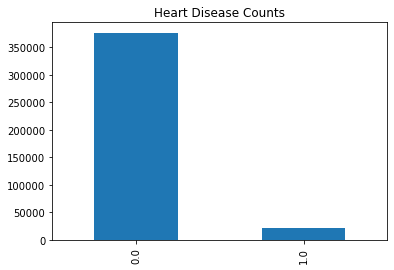

In [26]:
df['HeartDisease'].value_counts().plot.bar()
plt.title('Heart Disease Counts')
plt.show()

#### Training Split

In [22]:
df = df.sample(frac=1) # Shuffle data

In [23]:
tot = df.shape[0]
split = int(tot * 0.8)
df_train = df[:split]
df_test = df[split:]

Export

In [24]:
df_train.to_csv('./HeartDiseaseTrain.csv',index=False)
df_test.to_csv('./HeartDiseaseTest.csv', index=False)